In [2]:
# Imports and settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,ConfusionMatrixDisplay,)
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

BUSINESS_PATH  = 'business_cards_MDQ.parquet'
CONSUMER_PATH  = 'consumer_cards_MDQ.parquet'
MERCHANTS_PATH = 'merchants_reference.parquet'

In [3]:
#1 Loading data
df_biz = pd.read_parquet(BUSINESS_PATH)
df_con = pd.read_parquet(CONSUMER_PATH)
df_merchants = pd.read_parquet(MERCHANTS_PATH)
df_biz.rename(columns={'Is_recurring': 'is_recurring'}, inplace=True)
df_con.rename(columns={'Is_recurring': 'is_recurring'}, inplace=True)

# '1'-commercial  '0'-personal
df_biz['label'] = 1
df_con['label'] = 0

print(f'Business Cards: {df_biz["card_number"].nunique()} cards and {len(df_biz)} transactions')
print(f'Consumer Cards: {df_con["card_number"].nunique()} cards and {len(df_con)} transactions')
print(f'Merchants: {len(df_merchants)} records')

df_all = pd.concat([df_biz, df_con], ignore_index=True)
df_all['transaction_date'] = pd.to_datetime(df_all['transaction_date'])
df_all['transaction_timestamp'] = pd.to_datetime(df_all['transaction_timestamp'])
df_all = df_all.merge(df_merchants[['merchant_id', 'merchant_name', 'merchant_country', 'recurring_capable']], on='merchant_id', how='left')

Business Cards: 25000 cards and 2997593 transactions
Consumer Cards: 80000 cards and 9832487 transactions
Merchants: 2165 records


In [4]:
#2 cleaning
df_all = df_all[df_all['transaction_amount_kzt'] > 0].copy()
df_all['merchant_country']  = df_all['merchant_country'].fillna('Unknown')
df_all['recurring_capable'] = df_all['recurring_capable'].fillna(False)

In [5]:
#3 EDA
df_all['hour'] = df_all['transaction_timestamp'].dt.hour
df_all['day_of_week'] = df_all['transaction_timestamp'].dt.dayofweek

eda_summary = df_all.groupby('label').agg(
    avg_amount=('transaction_amount_kzt', 'mean'),
    median_amount=('transaction_amount_kzt', 'median'),
    unique_merchants=('merchant_id', 'nunique'),
    unique_mccs=('mcc', 'nunique'),
    pct_offline=('channel', lambda x: (x == 'offline').mean()),
    total_txns=('transaction_amount_kzt', 'count'),
).rename(index={0: 'personal (0)', 1: 'commercial (1)'})
#display(eda_summary.T)

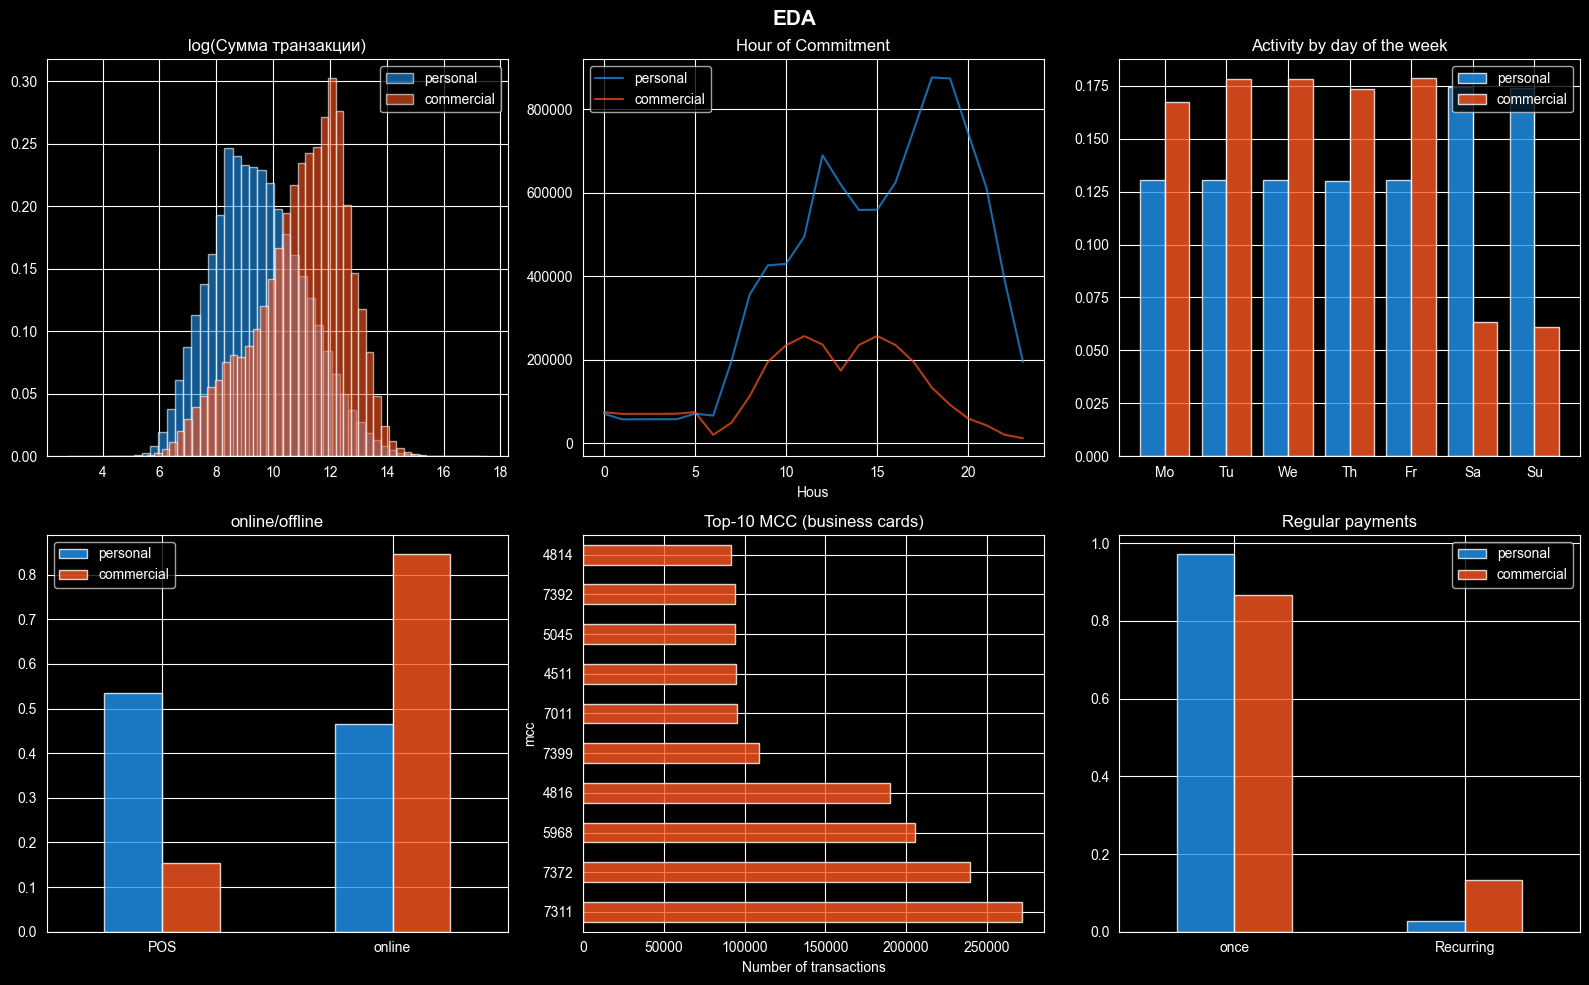

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('EDA', fontsize=15, fontweight='bold')

biz = df_all[df_all['label'] == 1]
con = df_all[df_all['label'] == 0]

# distribution of amounts
ax = axes[0, 0]
ax.hist(np.log1p(con['transaction_amount_kzt']), bins=50, alpha=0.6,
        label='personal', color='#2196F3', density=True)
ax.hist(np.log1p(biz['transaction_amount_kzt']), bins=50, alpha=0.6,
        label='commercial', color='#FF5722', density=True)
ax.set_title('log(Сумма транзакции)')
ax.legend()

# Hour of Commitment
ax = axes[0, 1]
con['hour'].value_counts().sort_index().plot(ax=ax, label='personal',color='#2196F3', alpha=0.7)
biz['hour'].value_counts().sort_index().plot(ax=ax, label='commercial',color='#FF5722', alpha=0.7)
ax.set_title('Hour of Commitment')
ax.set_xlabel('Hous')
ax.legend()

# day of the week
ax = axes[0, 2]
days = ['Mo','Tu','We','Th','Fr','Sa','Su']
con_dow = con['day_of_week'].value_counts().sort_index() / len(con)
biz_dow = biz['day_of_week'].value_counts().sort_index() / len(biz)
x = np.arange(7)
ax.bar(x - 0.2, con_dow, 0.4, label='personal', color='#2196F3', alpha=0.8)
ax.bar(x + 0.2, biz_dow, 0.4, label='commercial', color='#FF5722', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(days)
ax.set_title('Activity by day of the week')
ax.legend()

# online/offline
ax = axes[1, 0]
channel_data = pd.DataFrame({'personal': con['channel'].value_counts(normalize=True), 'commercial': biz['channel'].value_counts(normalize=True),})
channel_data.plot(kind='bar', ax=ax, color=['#2196F3', '#FF5722'], alpha=0.8)
ax.set_title('online/offline')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)

# 5. top MCC
ax = axes[1, 1]
top_mcc_biz = biz['mcc'].value_counts().head(10)
top_mcc_biz.plot(kind='barh', ax=ax, color='#FF5722', alpha=0.8)
ax.set_title('Top-10 MCC (business cards)')
ax.set_xlabel('Number of transactions')

# share recurring
ax = axes[1, 2]
rec_data = pd.DataFrame({'personal': con['is_recurring'].value_counts(normalize=True), 'commercial': biz['is_recurring'].value_counts(normalize=True),})
rec_data.rename(index={True: 'Recurring', False: 'once'}).plot(kind='bar', ax=ax, color=['#2196F3', '#FF5722'], alpha=0.8)
ax.set_title('Regular payments')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
df_all['hour'] = df_all['transaction_timestamp'].dt.hour
df_all['day_of_week'] = df_all['transaction_timestamp'].dt.dayofweek
df_all['is_weekend'] = df_all['day_of_week'].isin([5, 6]).astype(int)
df_all['is_business_hour'] = ((df_all['hour'] >= 9) & (df_all['hour'] < 18)).astype(int)
df_all['is_offline'] = (df_all['channel'] == 'offline').astype(int)
BUSINESS_MCCS = {
    '5040', '5045', '5065', '5085', '5169', #wholesale
    '7392', '7372', '7371', '7374', #IT and business services
    '5999', '5900', #other trade
    '4215', '4214', #couriers / freight transportation
    '8742', '8999', #consulting
    '5712', '5719', '5251', '5261', #building materials / tools
    '5411', '5912', '5499', #Products wholesale
    '7011', #hotels
    '4111', '4112', '4131', #transport
}
df_all['is_business_mcc'] = df_all['mcc'].isin(BUSINESS_MCCS).astype(int)

In [8]:
g = df_all.groupby('card_number')
feats = pd.DataFrame()

feats['total_txn_count'] = g['transaction_amount_kzt'].count()
feats['total_spend_kzt'] = g['transaction_amount_kzt'].sum()
feats['avg_txn_amount'] = g['transaction_amount_kzt'].mean()
feats['median_txn_amount'] = g['transaction_amount_kzt'].median()
feats['std_txn_amount'] = g['transaction_amount_kzt'].std().fillna(0)
feats['max_txn_amount'] = g['transaction_amount_kzt'].max()
feats['cv_txn_amount'] = feats['std_txn_amount'] / (feats['avg_txn_amount'] + 1)
feats['unique_merchants'] = g['merchant_id'].nunique()
feats['unique_mccs'] = g['mcc'].nunique()
feats['unique_countries'] = g['country'].nunique()
feats['merchant_concentration'] = feats['total_txn_count'] / (feats['unique_merchants'] + 1)
feats['pct_offline'] = g['is_offline'].mean()
feats['pct_business_hour'] = g['is_business_hour'].mean()
feats['pct_weekend'] = g['is_weekend'].mean()
feats['pct_business_mcc']  = g['is_business_mcc'].mean()
feats['pct_tokenized'] = g['tokenized'].mean()
feats['pct_recurring'] = g['is_recurring'].mean()
feats['active_days'] = g['transaction_date'].nunique()
feats['date_span_days'] = g['transaction_date'].agg(lambda x: (x.max() - x.min()).days)
feats['txn_per_active_day'] = feats['total_txn_count'] / (feats['active_days'] + 1)
feats['activity_regularity'] = feats['active_days'] / (feats['date_span_days'] + 1)
feats['pct_large_txn'] = g.apply(lambda x: (x['transaction_amount_kzt'] > 50_000).mean())
feats['pct_micro_txn'] = g.apply(lambda x: (x['transaction_amount_kzt'] < 1_000).mean())
feats['pct_round_amounts'] = g.apply(lambda x: (x['transaction_amount_kzt'] % 1000 == 0).mean())
feats['label'] = g['label'].first()
feats['bank_name'] = g['bank_name'].first()
feats['card_tier'] = g['card_tier'].first()
feats = feats.reset_index()

print(f'Feature matrix: {feats.shape[0]} kart × {feats.shape[1]} speakers\n')
print(feats['label'].value_counts().rename({1: 'commercial (1)', 0: 'personal (0)'}))
feats.head()

Feature matrix: 105000 kart × 28 speakers

label
personal (0)      80000
commercial (1)    25000
Name: count, dtype: int64


,card_number,total_txn_count,total_spend_kzt,avg_txn_amount,median_txn_amount,std_txn_amount,max_txn_amount,cv_txn_amount,unique_merchants,unique_mccs,...,active_days,date_span_days,txn_per_active_day,activity_regularity,pct_large_txn,pct_micro_txn,pct_round_amounts,label,bank_name,card_tier
0,5100610003025081,178,9651486,54221.831461,14499.0,92378.778008,745914,1.703688,9,9,...,105,181,1.679245,0.576923,0.275281,0.011236,0.0,1,Halyk,Business
1,5100610003044611,106,14353608,135411.396226,67810.0,198947.026012,1483178,1.469194,18,18,...,80,181,1.308642,0.439560,0.566038,0.028302,0.0,1,Halyk,Business
2,5100610003860784,148,13102356,88529.432432,56445.0,101798.906783,652796,1.149875,8,8,...,90,181,1.626374,0.494505,0.547297,0.054054,0.0,1,Halyk,Business
3,5100610005930965,43,14215001,330581.418605,168999.0,457017.109755,2137325,1.382460,7,7,...,40,180,1.048780,0.220994,0.883721,0.000000,0.0,0,Halyk,Standard
4,5100610005962109,119,1303168,10950.991597,5886.0,23120.959998,223504,2.111119,46,43,...,82,180,1.433735,0.453039,0.033613,0.092437,0.0,0,Halyk,Standard


In [9]:
# preparing training and test samples
FEATURE_COLS = [c for c in feats.columns if c not in ['card_number', 'label', 'bank_name', 'card_tier'] and feats[c].dtype in [np.float64, np.int64, float, int]]

X = feats[FEATURE_COLS].copy().fillna(0).replace([np.inf, -np.inf], 0)
y = feats['label'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

print(f'Signs : {len(FEATURE_COLS)}')

Signs : 24


In [10]:
# model training and comparison
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            class_weight='balanced', max_iter=1000, C=0.1,
            random_state=RANDOM_STATE
        ))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_leaf=5,
        class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, min_samples_leaf=10, random_state=RANDOM_STATE
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}

for name, model in models.items():
    print(f'We train: {name}')
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    model.fit(X_train, y_train)
    results[name] = {'model': model, 'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std()}
    print(f'   CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

best_name  = max(results, key=lambda k: results[k]['cv_mean'])
best_model = results[best_name]['model']
print(f'\n Best model: {best_name}')

We train: Logistic Regression
   CV ROC-AUC: 1.0000 ± 0.0000
We train: Random Forest
   CV ROC-AUC: 1.0000 ± 0.0000
We train: Gradient Boosting
   CV ROC-AUC: 1.0000 ± 0.0000

 Best model: Gradient Boosting


In [11]:
y_prob = best_model.predict_proba(X_test)[:, 1]
y_pred = best_model.predict(X_test)

roc_auc = roc_auc_score(y_test, y_prob)
pr_auc  = average_precision_score(y_test, y_prob)

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores    = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_thresh  = thresholds[np.argmax(f1_scores[:-1])]
y_pred_tuned = (y_prob >= best_thresh).astype(int)

print(f'ROC-AUC : {roc_auc:.4f}')
print(f'PR-AUC  : {pr_auc:.4f}')
print(f'Optimal threshold: {best_thresh:.3f}')
print(classification_report(y_test, y_pred_tuned,
      target_names=['Private', 'Commercial'], digits=4))

ROC-AUC : 1.0000
PR-AUC  : 1.0000
Optimal threshold: 0.173
              precision    recall  f1-score   support

     Private     0.9998    0.9998    0.9998     16000
  Commercial     0.9994    0.9994    0.9994      5000

    accuracy                         0.9997     21000
   macro avg     0.9996    0.9996    0.9996     21000
weighted avg     0.9997    0.9997    0.9997     21000



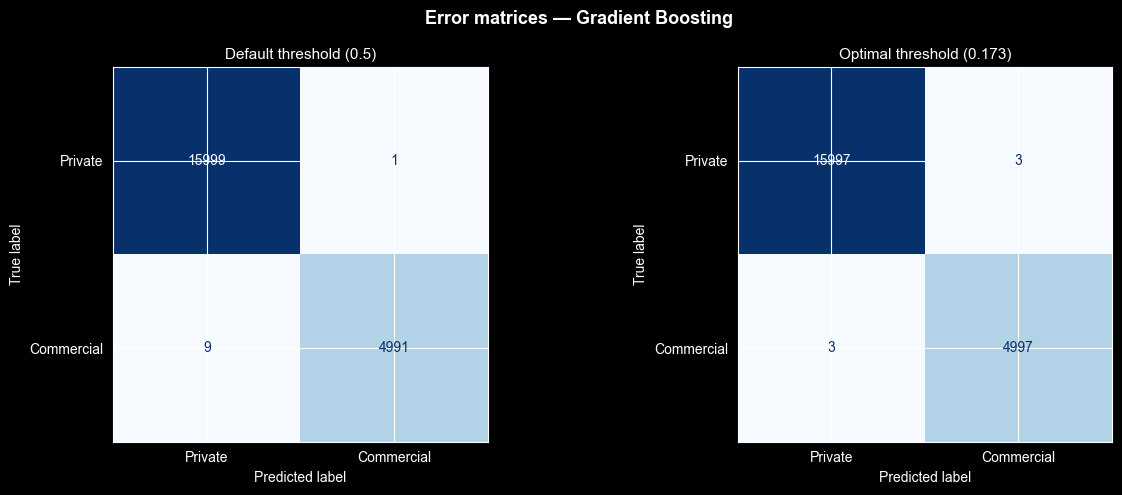

In [12]:
# error matrices
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Error matrices — {best_name}', fontsize=13, fontweight='bold')

for ax, preds, title in zip(axes, [y_pred, y_pred_tuned], ['Default threshold (0.5)', f'Optimal threshold ({best_thresh:.3f})']):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Private', 'Commercial'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

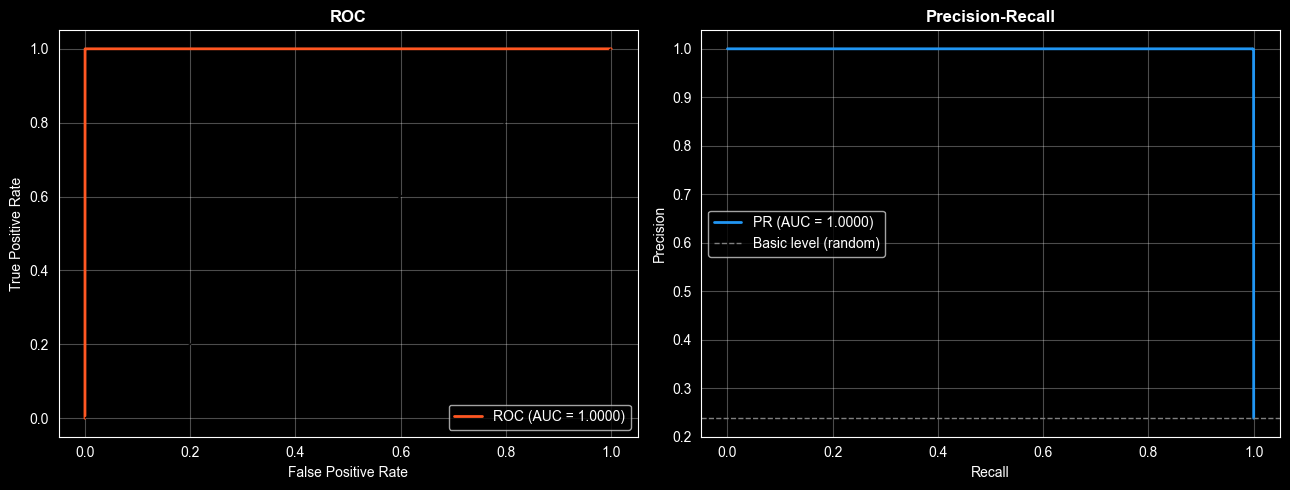

In [13]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
axes[0].plot(fpr, tpr, color='#FF5722', lw=2,
             label=f'ROC (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Precision-Recall
axes[1].plot(recalls[:-1], precisions[:-1], color='#2196F3', lw=2,
             label=f'PR (AUC = {pr_auc:.4f})')
axes[1].axhline(y=feats['label'].mean(), color='gray', linestyle='--',
                lw=1, label='Basic level (random)')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
summary_rows = []
for name, res in results.items():
    yp = res['model'].predict_proba(X_test)[:, 1]
    summary_rows.append({
        'Model': name,
        'CV ROC-AUC': f"{res['cv_mean']:.4f} ± {res['cv_std']:.4f}",
        'Test ROC-AUC': f'{roc_auc_score(y_test, yp):.4f}',
        'Test PR-AUC': f'{average_precision_score(y_test, yp):.4f}',
    })

summary_df = pd.DataFrame(summary_rows).set_index('Model')
display(summary_df)

,CV ROC-AUC,Test ROC-AUC,Test PR-AUC
Model,,,
Logistic Regression,1.0000 ± 0.0000,1.0000,1.0000
Random Forest,1.0000 ± 0.0000,1.0000,1.0000
Gradient Boosting,1.0000 ± 0.0000,1.0000,1.0000


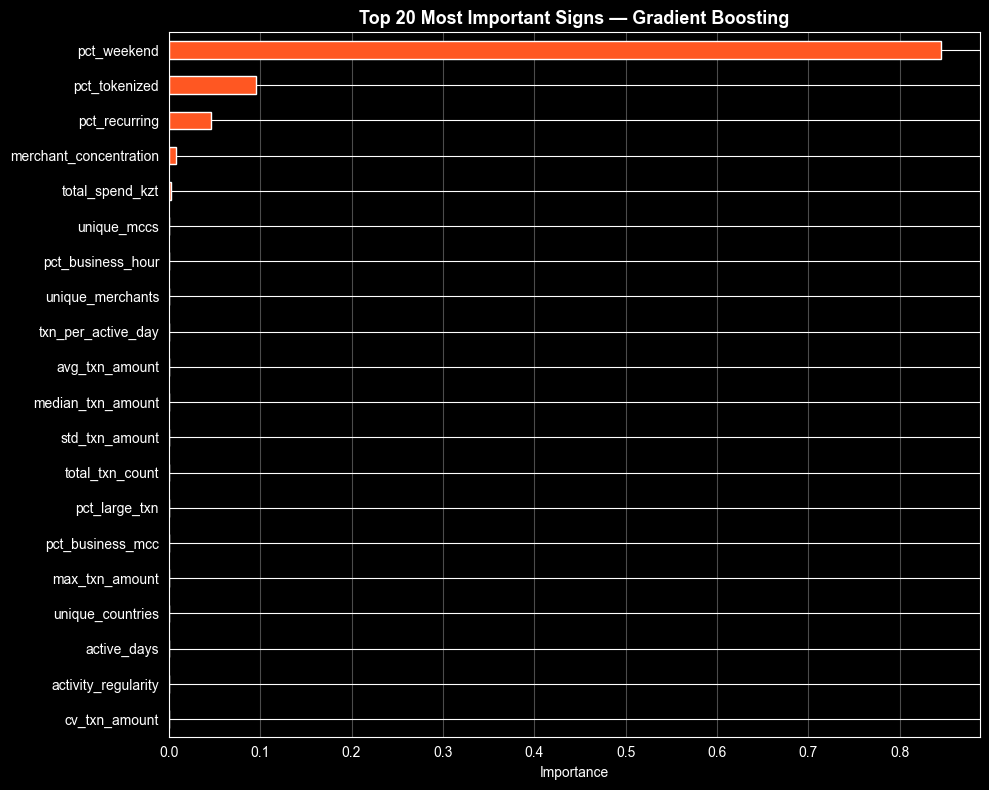

Top 10 Signs:


,Importance
pct_weekend,0.845707
pct_tokenized,0.094993
pct_recurring,0.045958
merchant_concentration,0.007676
total_spend_kzt,0.002885
unique_mccs,0.000709
pct_business_hour,0.000607
unique_merchants,0.000400
txn_per_active_day,0.000271
avg_txn_amount,0.000166


In [16]:
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'named_steps'):
    clf = best_model.named_steps.get('clf')
    importances = np.abs(clf.coef_[0]) if hasattr(clf, 'coef_') else None
else:
    importances = None

if importances is not None:
    feat_imp = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=False)
    top20 = feat_imp.head(20)

    fig, ax = plt.subplots(figsize=(10, 8))
    top20.sort_values().plot(kind='barh', ax=ax, color='#FF5722')
    ax.set_title(f'Top 20 Most Important Signs — {best_name}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance')
    ax.grid(alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('Top 10 Signs:')
    display(feat_imp.head(10).to_frame('Importance'))

In [17]:
# Consumer Card Scoring
consumer_feats = feats[feats['label'] == 0].copy()
X_consumers = consumer_feats[FEATURE_COLS].fillna(0).replace([np.inf, -np.inf], 0)

consumer_feats['commercial_score'] = best_model.predict_proba(X_consumers)[:, 1]
consumer_feats['predicted_commercial']= (consumer_feats['commercial_score'] >= best_thresh).astype(int)

n_flagged = consumer_feats['predicted_commercial'].sum()
n_total   = len(consumer_feats)
print(f'Demand cards analyzed : {n_total:,}')
print(f'Marked as commercial : {n_flagged:,} ({n_flagged/n_total:.1%})')

Demand cards analyzed : 80,000
Marked as commercial : 3 (0.0%)


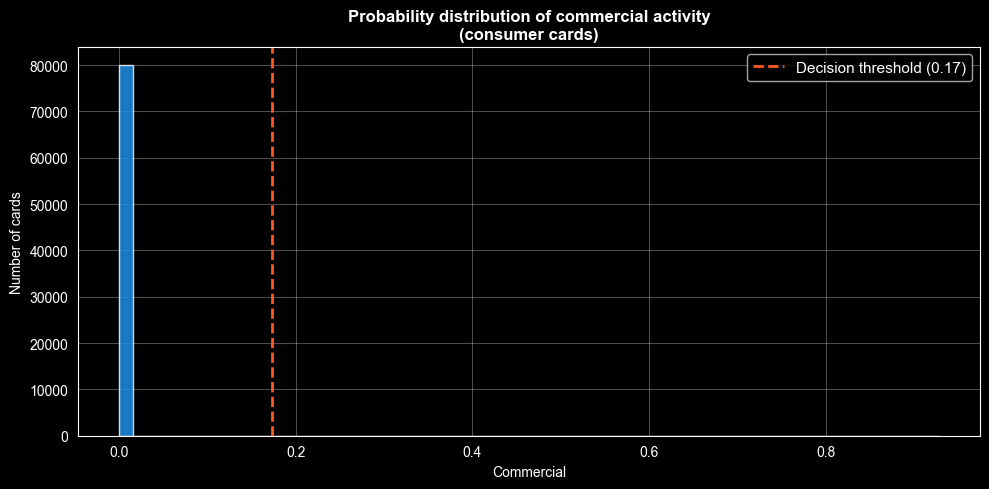

In [18]:
# Distribution of speeds
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(consumer_feats['commercial_score'], bins=60,
        color='#2196F3', alpha=0.8, edgecolor='white')
ax.axvline(best_thresh, color='#FF5722', linestyle='--', lw=2,
           label=f'Decision threshold ({best_thresh:.2f})')
ax.set_title('Probability distribution of commercial activity\n'
             '(consumer cards)', fontsize=12, fontweight='bold')
ax.set_xlabel('Commercial')
ax.set_ylabel('Number of cards')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# Profile of Highly Confident Candidates
high_conf = consumer_feats[consumer_feats['commercial_score'] > 0.80]
print(f'Карты с уверенностью > 80%: {len(high_conf):,}')

if len(high_conf) > 0:
    profile = high_conf[FEATURE_COLS].describe().loc[['mean', '50%']].T
    profile.columns = ['Среднее', 'Медиана']
    display(profile)

Карты с уверенностью > 80%: 1


,Среднее,Медиана
total_txn_count,4.400000e+01,4.400000e+01
total_spend_kzt,4.835109e+06,4.835109e+06
avg_txn_amount,1.098888e+05,1.098888e+05
median_txn_amount,8.146900e+04,8.146900e+04
std_txn_amount,1.108165e+05,1.108165e+05
max_txn_amount,5.826220e+05,5.826220e+05
cv_txn_amount,1.008432e+00,1.008432e+00
unique_merchants,1.500000e+01,1.500000e+01
unique_mccs,1.500000e+01,1.500000e+01
unique_countries,4.000000e+00,4.000000e+00


In [22]:
CONVERSION_RATE  = 0.30
FEE_UPLIFT_PCT   = 0.005  # +0.5% interchange

# Annualization (data for 6 months)
avg_annual_spend = consumer_feats.loc[
    consumer_feats['predicted_commercial'] == 1, 'total_spend_kzt'
].mean() * 2

potential_converted = int(n_flagged * CONVERSION_RATE)
additional_revenue = potential_converted * avg_annual_spend * FEE_UPLIFT_PCT

print('Business Value Assessment')
print('─' * 45)
print(f'Marked cards : {n_flagged:,}')
print(f'Expected conversion (30%) : {potential_converted:,}')
print(f'Average annual expenses : {avg_annual_spend:,.0f} KZT')
print(f'Additional income/year : {additional_revenue:,.0f} KZT')

Business Value Assessment
─────────────────────────────────────────────
Marked cards : 3
Expected conversion (30%) : 0
Average annual expenses : 12,595,064 KZT
Additional income/year : 0 KZT
